### ***Import Libraries & Load Data***

In [43]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 2. Load Data
df = pd.read_csv('./Data_Stroke/stroke_data_raw.csv')

df.drop("id", axis=1, inplace=True)

# Preview
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### ***Data Type Conversion***

In [44]:
# 3. Convert Categorical Features
def convert_cat(df, features):
    """Convert type of feature => Categorical"""
    for feature in features:
        df[feature] = df[feature].astype('category')

# Các cột định tính trong Stroke
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                'work_type', 'Residence_type', 'smoking_status', 'stroke']

convert_cat(df, cat_features)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5110 non-null   category
 1   age                5110 non-null   float64 
 2   hypertension       5110 non-null   category
 3   heart_disease      5110 non-null   category
 4   ever_married       5110 non-null   category
 5   work_type          5110 non-null   category
 6   Residence_type     5110 non-null   category
 7   avg_glucose_level  5110 non-null   float64 
 8   bmi                4909 non-null   float64 
 9   smoking_status     5110 non-null   category
 10  stroke             5110 non-null   category
dtypes: category(8), float64(3)
memory usage: 161.0 KB


In [45]:
df.describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


In [46]:
df.describe(include='category')

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
count,5110,5110,5110,5110,5110,5110,5110,5110
unique,3,2,2,2,5,2,4,2
top,Female,0,0,Yes,Private,Urban,never smoked,0
freq,2994,4612,4834,3353,2925,2596,1892,4861


## ***Exploratory Data Analysis (EDA)***

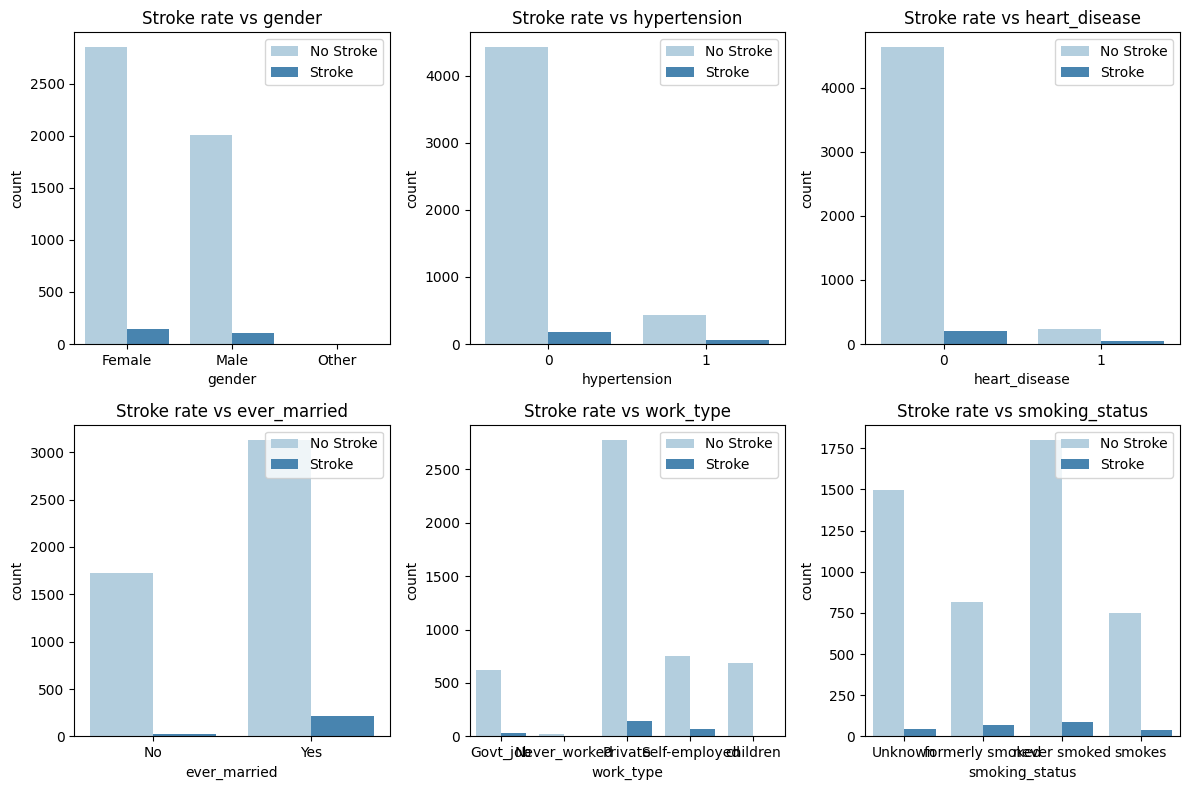

In [47]:
# 4. EDA Categorical Features vs Target
cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'smoking_status']

n_rows = 2
n_clos = 3

fig, ax = plt.subplots(n_rows, n_clos, figsize=(n_clos*4, n_rows*4))

for c in range(n_clos):
    for r in range(n_rows):
        i = r*n_clos + c
        if i < len(cols):
            ax_i = ax[r,c]
            # Thay 'Survived' bằng 'stroke'
            sns.countplot(data=df, x=cols[i], hue='stroke', ax=ax_i, palette="Blues")
            ax_i.set_title(f"Stroke rate vs {cols[i]}")
            ax_i.legend(title='', loc='upper right', labels=['No Stroke', 'Stroke'])

plt.tight_layout()
plt.show()

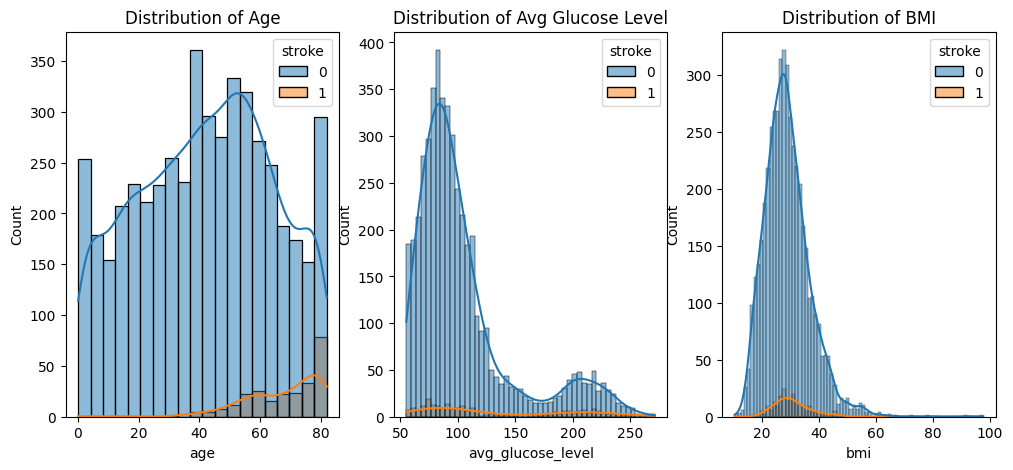

In [48]:
# 5. EDA Numerical Features
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
sns.histplot(df, x='age', kde=True, hue='stroke', ax=ax[0])
ax[0].set_title('Distribution of Age')

sns.histplot(df, x='avg_glucose_level', kde=True, hue='stroke', ax=ax[1])
ax[1].set_title('Distribution of Avg Glucose Level')

sns.histplot(df, x='bmi', kde=True, hue='stroke', ax=ax[2])
ax[2].set_title('Distribution of BMI')
plt.show()

### ***BMI group***

<Axes: xlabel='bmi', ylabel='Count'>

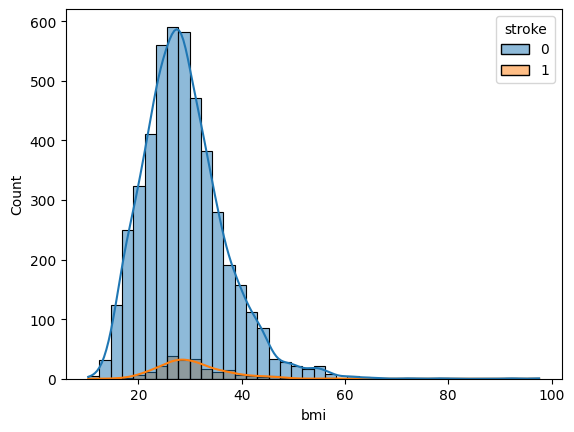

In [49]:
sns.histplot(df , bins= 40 , x = 'bmi' , kde = "True", hue = 'stroke')

In [50]:
bmi_group = pd.cut(df['bmi'], bins = [-np.inf, 18.5, 25.0, 30.0, np.inf], labels = ['Underweight', 'Normal', 'Overweight', 'Obese'],right=False)
bmi_group

0            Obese
1              NaN
2            Obese
3            Obese
4           Normal
           ...    
5105           NaN
5106         Obese
5107         Obese
5108    Overweight
5109    Overweight
Name: bmi, Length: 5110, dtype: category
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']

<Axes: xlabel='bmi', ylabel='count'>

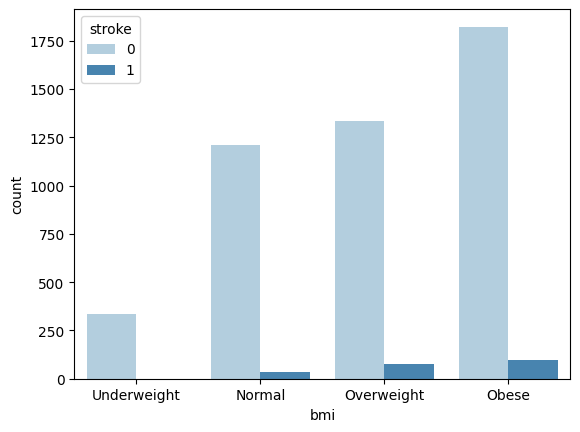

In [51]:
sns.countplot(x=bmi_group , hue=df['stroke'], palette='Blues')

### ***Feature Engineering & Missing Value***

In [ ]:
# Kiểm tra missing
print(f"BMI missing before: {df['bmi'].isnull().sum()}")

# 6. Fill Missing Values 
df['bmi'] = df.groupby(['gender', 'work_type'])['bmi'].transform(lambda x: x.fillna(x.median()))

df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print(f"BMI missing after: {df['bmi'].isnull().sum()}")

BMI missing before: 201
BMI missing after: 0


/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_47055/2763334572.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['bmi'] = df.groupby(['gender', 'work_type'])['bmi'].transform(lambda x: x.fillna(x.median()))


### ***Data Preprocessing Pipeline***

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Định nghĩa lại các cột
num_features = ['age', 'avg_glucose_level', 'bmi']
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Pipeline cho số (Scale)
num_transformer = Pipeline(steps=[
    ('scale', StandardScaler())
])

# Pipeline cho chữ (OneHot)
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Gộp lại
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Tách X, y
X = df.drop('stroke', axis=1)
y = df['stroke']

# Fit và Transform dữ liệu
X_preprocessed = preprocessor.fit_transform(X)

### ***Model Comparison***

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_47055/4127404293.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model_name", y='score', data=cv_df, palette='Blues', showmeans=True)


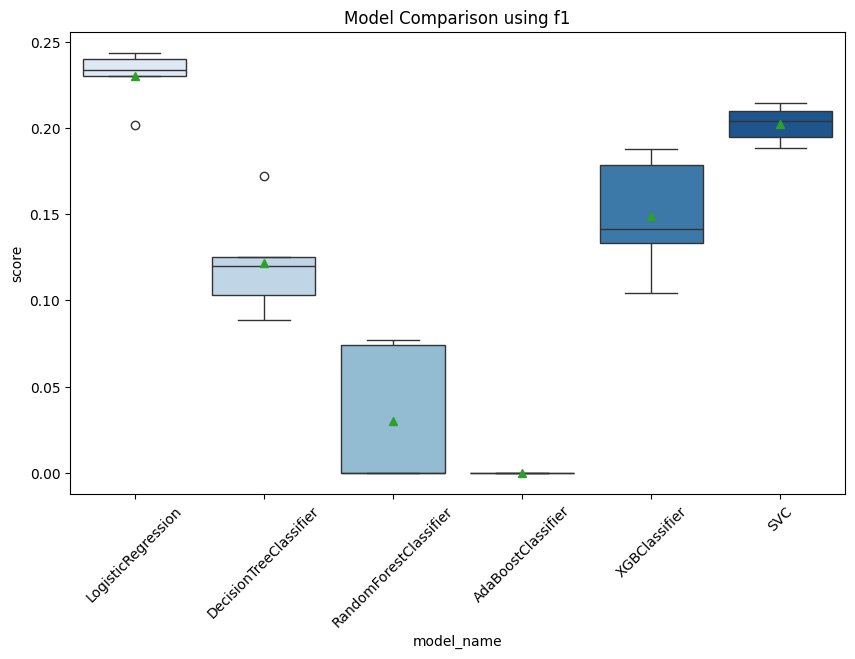

                            Mean  Standard Deviation
model_name                                          
LogisticRegression      0.229878            0.016551
SVC                     0.202294            0.010762
XGBClassifier           0.148879            0.034105
DecisionTreeClassifier  0.121805            0.031508
RandomForestClassifier  0.030199            0.041365
AdaBoostClassifier      0.000000            0.000000


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pandas as pd

# Định nghĩa Models (Thêm class_weight='balanced' để xử lý Imbalanced Data)
seed = 42
models = [
    LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced', random_state=seed),
    DecisionTreeClassifier(random_state=seed, class_weight='balanced'),
    RandomForestClassifier(random_state=seed, class_weight='balanced'),
    AdaBoostClassifier(random_state=seed), # AdaBoost không có class_weight nhưng mạnh
    XGBClassifier(eval_metric='logloss', scale_pos_weight=20, random_state=seed), # scale_pos_weight cho XGBoost
    SVC(random_state=seed, class_weight='balanced')
]

# Sử dụng lại hàm của bạn (có chỉnh nhẹ metrics mặc định)
def generate_baseline_results(models, X, y, metrics='roc_auc', cv=5, plot_results=False):
    kfold = StratifiedKFold(cv, shuffle=True, random_state=seed)
    entries = []
    for model in models:
        model_name = model.__class__.__name__
        # Chuyển y sang dạng số nguyên nếu cần (cho XGBoost/CatBoost)
        scores = cross_val_score(model, X, y.astype(int), scoring=metrics, cv=kfold)
        for fold_idx, score in enumerate(scores):
            entries.append((model_name, fold_idx, score))
    
    cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_id', 'score'])
    
    # Tính toán mean và std
    mean = cv_df.groupby('model_name')['score'].mean()
    std = cv_df.groupby('model_name')['score'].std()
    baseline_result = pd.concat([mean, std], axis=1, ignore_index=True)
    baseline_result.columns = ['Mean', 'Standard Deviation']
    baseline_result.sort_values(by=['Mean'], ascending=False, inplace=True)
    
    if plot_results:
        import seaborn as sns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        sns.boxplot(x="model_name", y='score', data=cv_df, palette='Blues', showmeans=True)
        plt.title(f'Model Comparison using {metrics}')
        plt.xticks(rotation=45)
        plt.show()
        
    return baseline_result

# Chạy hàm
results = generate_baseline_results(models, X_preprocessed, y, metrics='f1', plot_results=True)
print(results)

### ***Final Steps***

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



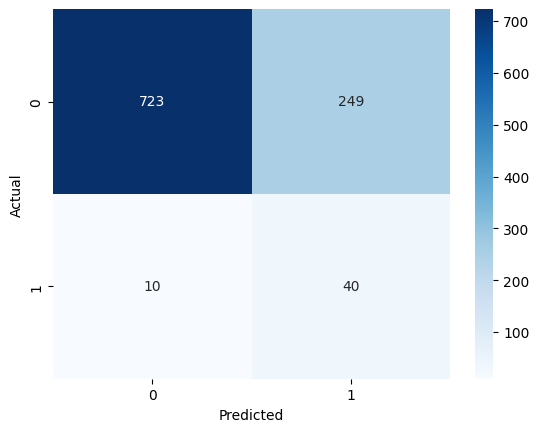

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=seed, stratify=y)

# Giả sử Logistic Regression hoặc XGBoost tốt nhất
final_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=seed)
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)

# Đánh giá (Quan trọng nhất là Recall của class 1 - Stroke)
print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()